In [7]:
# Elvara optimization research
import warnings
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive, and thus cannot be shown",
)
warnings.filterwarnings(
    "ignore",
    message="Solution may be inaccurate.*",
)


def plot_commodity(ticker, name, color):
    df = yf.download(ticker, period="5y", auto_adjust=False, progress=False)
    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"
    series = df[price_col].squeeze().dropna()

    sns.set_theme(style="darkgrid")
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.lineplot(x=series.index, y=series.values, ax=ax, color=color, linewidth=1)
    ax.set_title(f"{name} Daily Price - Past 5 Years", fontsize=16, fontweight="bold")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price (USD)", fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

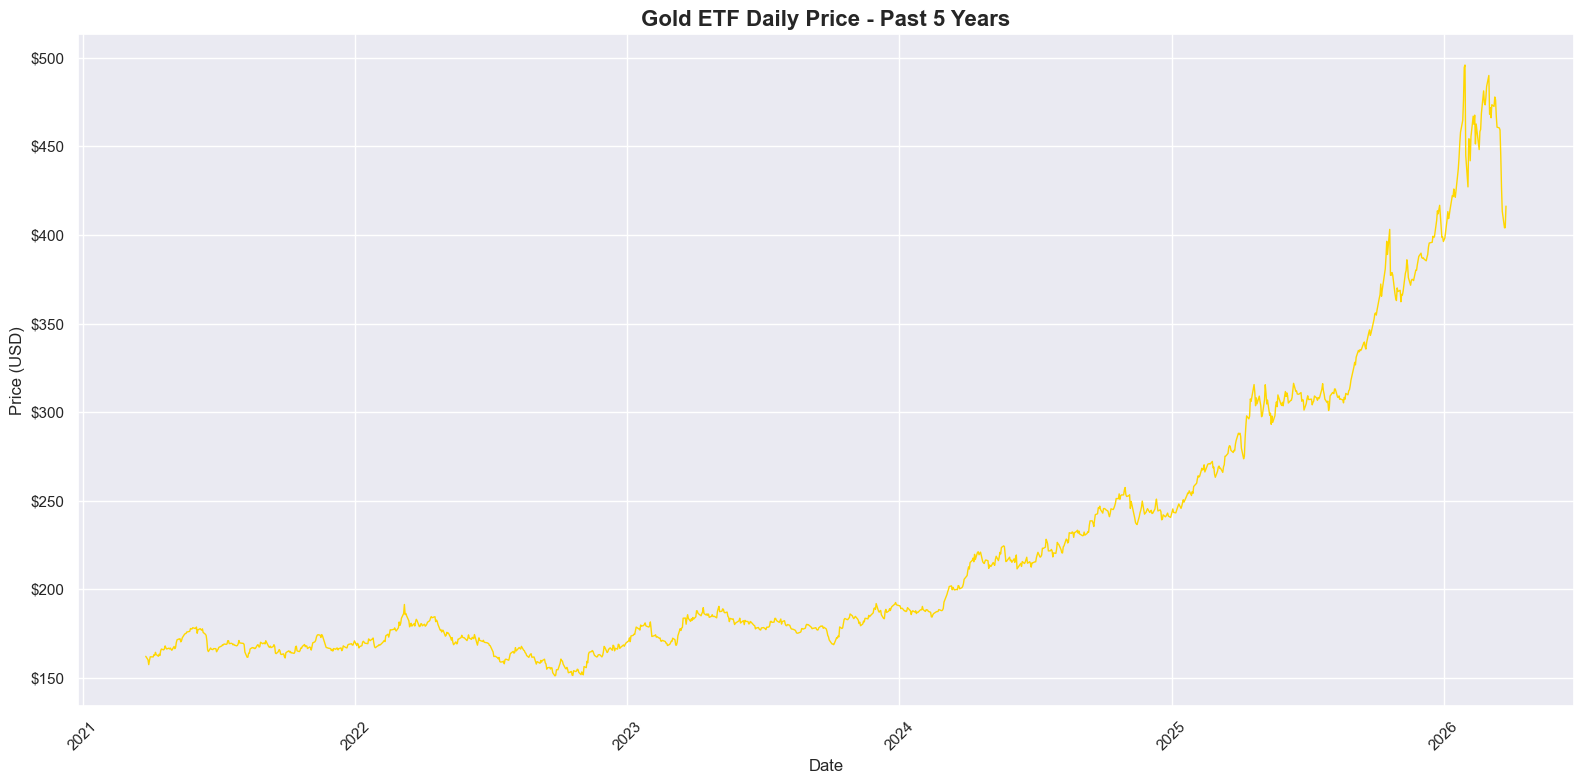

In [8]:
plot_commodity("GLD", "Gold ETF", "gold")

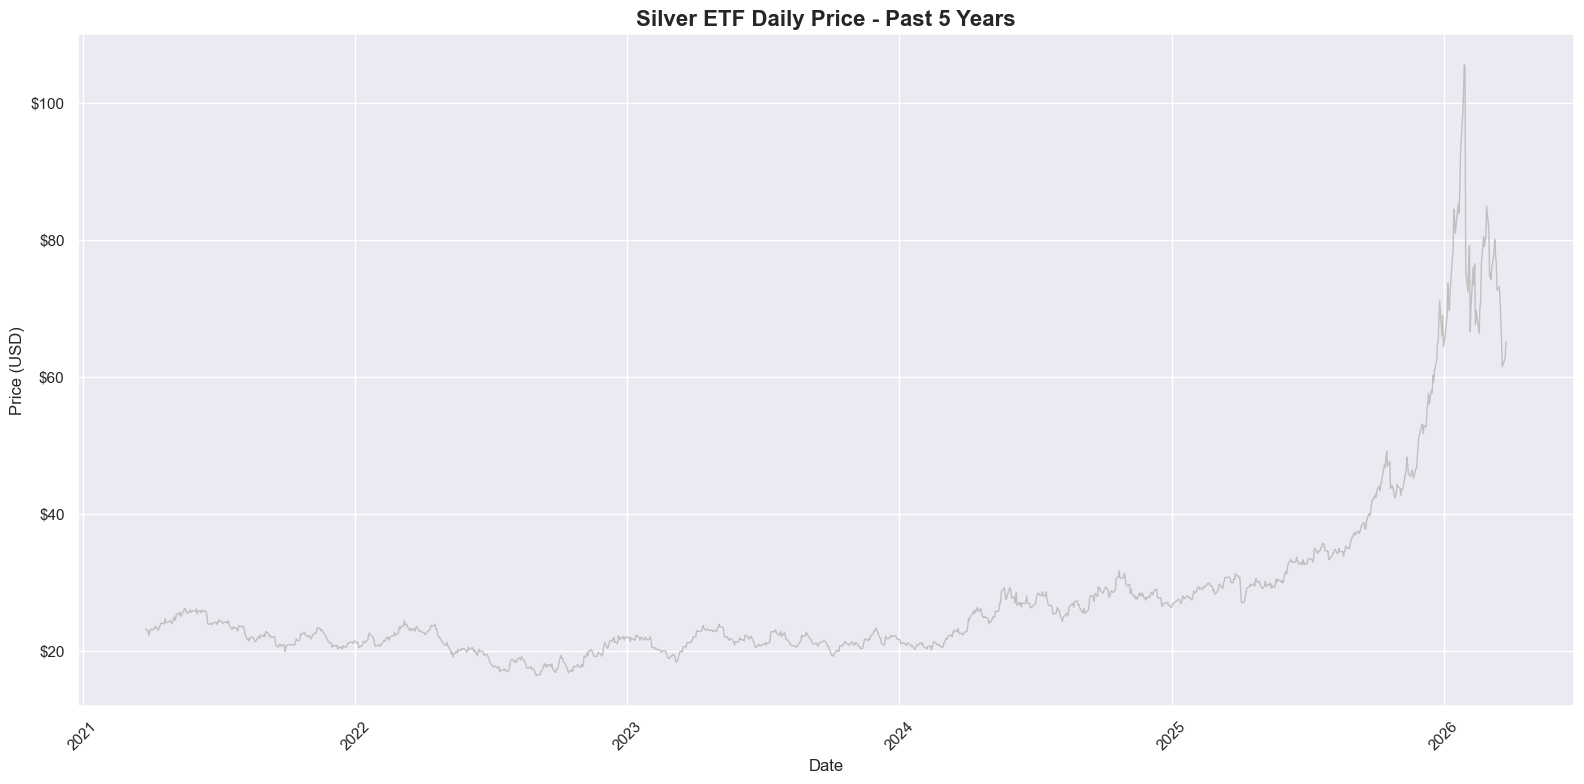

In [9]:
plot_commodity("SLV", "Silver ETF", "silver")

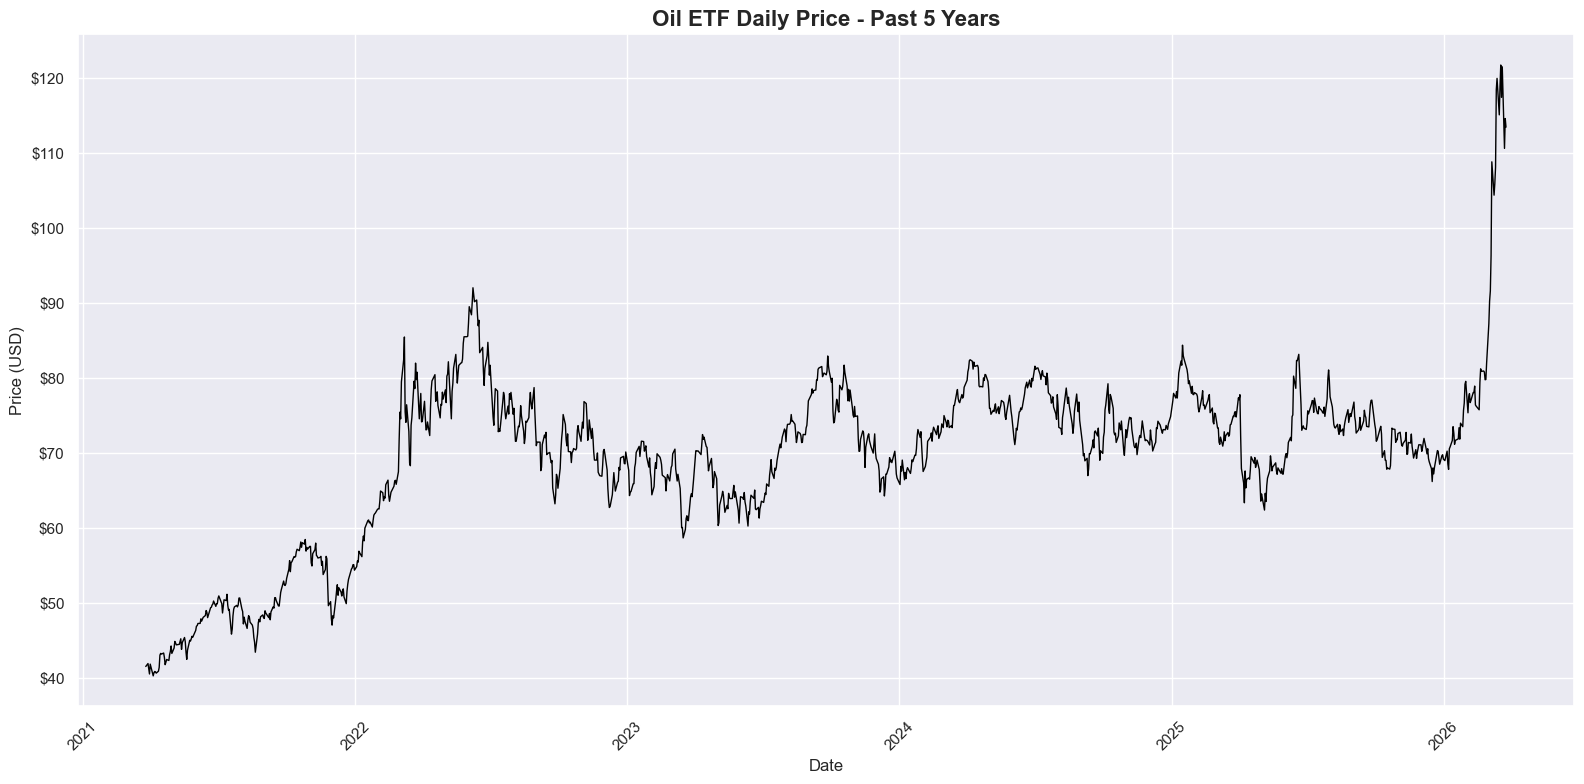

In [10]:
plot_commodity("USO", "Oil ETF", "black")

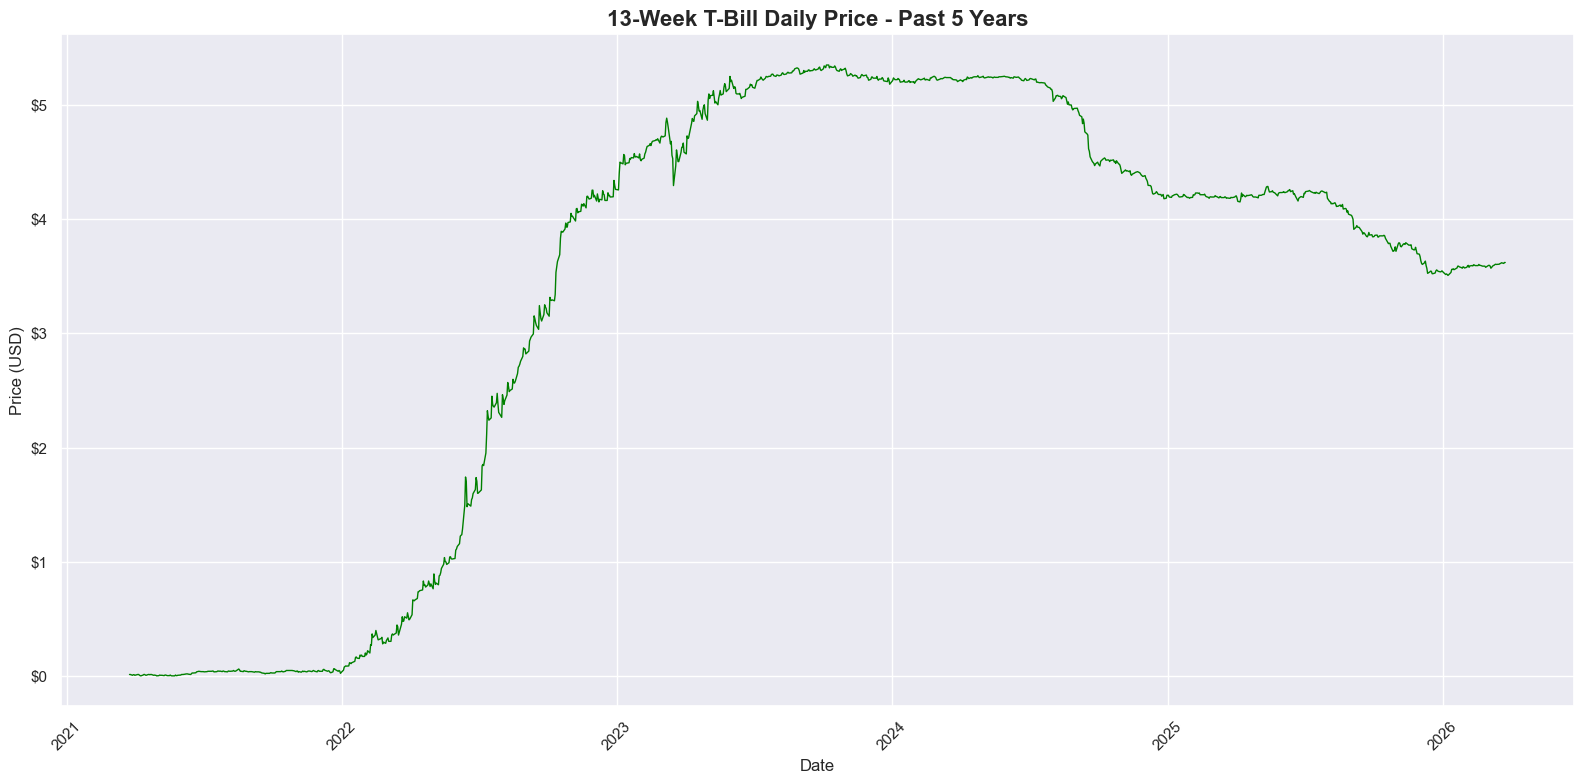

In [11]:
plot_commodity("^IRX", "13-Week T-Bill", "green")

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from skfolio import RiskMeasure
from skfolio.optimization import MeanRisk, ObjectiveFunction
from skfolio.preprocessing import prices_to_returns

# Real World Assets (RWA) Portfolio ETF proxies
# Using ETFs keeps the assets on a consistent, investable footing.
tickers = {
    "Gold": "GLD",
    "Silver": "SLV",
    "Oil": "USO",
    "REIT": "VNQ",
    "Treasury": "TLT",
    "EnergyInfra": "AMLP",
    "Agri": "DBA",
}

START_DATE = "2021-03-01"
END_DATE = "2026-03-03"

raw_prices = yf.download(
    list(tickers.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)
price_field = "Adj Close" if "Adj Close" in raw_prices.columns.get_level_values(0) else "Close"
prices = raw_prices[price_field][list(tickers.values())].copy()
prices.columns = list(tickers.keys())
prices = prices.dropna()

X = prices_to_returns(prices)

# Risk-free series used inside each walk-forward training fold.
tbill = yf.download(
    "^IRX",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)["Close"].squeeze().dropna()
tbill_daily = (tbill / 100) / 252

MIN_TRAIN_DAYS = 504
TEST_DAYS = 63
STEP_DAYS = TEST_DAYS
TRANSACTION_COST_BPS = 10
COST_RATE = TRANSACTION_COST_BPS / 10_000
TRADING_DAYS = 252
INITIAL = 1_000_000
BASE_MIN_WEIGHT = 0.05
BASE_MAX_WEIGHT = 0.35
BOOTSTRAP_SAMPLES = 1_000
BOOTSTRAP_BLOCK_DAYS = TEST_DAYS
BOOTSTRAP_SEED = 42


def walk_forward_slices(index, min_train_days, test_days, step_days=None):
    step_days = test_days if step_days is None else step_days
    folds = []
    train_end = min_train_days

    while train_end + test_days <= len(index):
        folds.append((slice(0, train_end), slice(train_end, train_end + test_days)))
        train_end += step_days

    return folds



def compute_train_risk_free_rate(tbill_daily, train_index):
    aligned = tbill_daily.reindex(train_index).ffill().dropna()
    return float(aligned.mean()) if not aligned.empty else 0.0



def apply_rebalance_cost(returns, turnover, cost_rate):
    returns = returns.copy()
    cost = float(turnover * cost_rate)

    if not returns.empty and cost > 0:
        returns.iloc[0] = (1 - cost) * (1 + returns.iloc[0]) - 1

    return returns, cost



def compute_end_weights(asset_returns, start_weights):
    gross_returns = (1 + asset_returns).prod(axis=0).to_numpy(dtype=float)
    end_values = np.asarray(start_weights, dtype=float) * gross_returns
    total = float(end_values.sum())

    if total <= 0:
        return np.asarray(start_weights, dtype=float)

    return end_values / total


folds = walk_forward_slices(X.index, MIN_TRAIN_DAYS, TEST_DAYS, STEP_DAYS)
if not folds:
    raise ValueError("Not enough observations for the chosen walk-forward settings.")

oos_start = X.index[folds[0][1].start]
oos_end = X.index[folds[-1][1].stop - 1]

print(f"Download window: {START_DATE} to {END_DATE}")
print(f"Assets: {list(prices.columns)}")
print(f"Observations: {len(X)} total return rows")
print(f"Walk-forward folds: {len(folds)}")
print(f"OOS period: {oos_start.date()} to {oos_end.date()}")
print(
    f"Min train: {MIN_TRAIN_DAYS} days | Test: {TEST_DAYS} days | "
    f"Step: {STEP_DAYS} days | Cost: {TRANSACTION_COST_BPS} bps"
)

Download window: 2021-03-01 to 2026-03-03
Assets: ['Gold', 'Silver', 'Oil', 'REIT', 'Treasury', 'EnergyInfra', 'Agri']
Observations: 1256 total return rows
Walk-forward folds: 11
OOS period: 2023-03-02 to 2025-12-03
Min train: 504 days | Test: 63 days | Step: 63 days | Cost: 10 bps


In [4]:
# Walk-forward optimizer backtest
strategy_configs = {
    "CVaR": {"risk_measure": RiskMeasure.CVAR},
    "Semi-Var": {"risk_measure": RiskMeasure.SEMI_VARIANCE},
    "Variance": {"risk_measure": RiskMeasure.VARIANCE},
    "EVaR": {"risk_measure": RiskMeasure.EVAR, "solver": "CLARABEL", "scale_constraints": 1e-1},
    "Worst": {"risk_measure": RiskMeasure.WORST_REALIZATION},
    "Max DD": {"risk_measure": RiskMeasure.MAX_DRAWDOWN},
}


def run_walk_forward_strategy(
    model_kwargs,
    folds_input=None,
    cost_rate=None,
    min_weight=BASE_MIN_WEIGHT,
    max_weight=BASE_MAX_WEIGHT,
):
    folds_input = folds if folds_input is None else folds_input
    cost_rate = COST_RATE if cost_rate is None else cost_rate

    oos_returns = []
    rebalance_weights = []
    current_weights = np.zeros(len(prices.columns))
    total_cost = 0.0
    fallback_count = 0

    for train_slice, test_slice in folds_input:
        X_train = X.iloc[train_slice].copy()
        X_test = X.iloc[test_slice].copy()
        fold_risk_free_rate = compute_train_risk_free_rate(tbill_daily, X_train.index)

        try:
            model = MeanRisk(
                objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
                min_weights=min_weight,
                max_weights=max_weight,
                risk_free_rate=fold_risk_free_rate,
                **model_kwargs,
            )
            model.fit(X_train)
            portfolio = model.predict(X_test)
            target_weights = np.asarray(model.weights_, dtype=float)
            fold_returns = pd.Series(portfolio.returns, index=X_test.index)
        except Exception:
            if current_weights.sum() == 0:
                raise

            target_weights = current_weights.copy()
            fold_returns = X_test.mul(target_weights, axis=1).sum(axis=1)
            fallback_count += 1

        turnover = float(np.abs(target_weights - current_weights).sum())
        fold_returns, fold_cost = apply_rebalance_cost(fold_returns, turnover, cost_rate)

        oos_returns.append(fold_returns)
        rebalance_weights.append(target_weights.copy())
        total_cost += fold_cost
        current_weights = compute_end_weights(X_test, target_weights)

    return {
        "returns": pd.concat(oos_returns),
        "avg_weights": pd.Series(np.mean(rebalance_weights, axis=0), index=prices.columns),
        "last_weights": pd.Series(rebalance_weights[-1], index=prices.columns),
        "total_cost": total_cost,
        "n_rebalances": len(rebalance_weights),
        "fallback_count": fallback_count,
    }



def run_equal_weight_strategy(folds_input=None, cost_rate=None):
    folds_input = folds if folds_input is None else folds_input
    cost_rate = COST_RATE if cost_rate is None else cost_rate

    target_weights = np.repeat(1 / len(prices.columns), len(prices.columns))
    oos_returns = []
    rebalance_weights = []
    current_weights = np.zeros(len(prices.columns))
    total_cost = 0.0

    for _, test_slice in folds_input:
        X_test = X.iloc[test_slice].copy()
        fold_returns = X_test.mul(target_weights, axis=1).sum(axis=1)
        turnover = float(np.abs(target_weights - current_weights).sum())
        fold_returns, fold_cost = apply_rebalance_cost(fold_returns, turnover, cost_rate)

        oos_returns.append(fold_returns)
        rebalance_weights.append(target_weights.copy())
        total_cost += fold_cost
        current_weights = compute_end_weights(X_test, target_weights)

    return {
        "returns": pd.concat(oos_returns),
        "avg_weights": pd.Series(np.mean(rebalance_weights, axis=0), index=prices.columns),
        "last_weights": pd.Series(rebalance_weights[-1], index=prices.columns),
        "total_cost": total_cost,
        "n_rebalances": len(rebalance_weights),
        "fallback_count": 0,
    }


strategy_runs = {
    name: run_walk_forward_strategy(config)
    for name, config in strategy_configs.items()
}
strategy_runs["Equal Weight"] = run_equal_weight_strategy()

oos_index = next(iter(strategy_runs.values()))["returns"].index
for name, run in strategy_runs.items():
    print(
        f"{name}: {len(run['returns'])} OOS days | rebalances={run['n_rebalances']} | "
        f"cost drag={run['total_cost'] * 100:.2f}% | fallbacks={run['fallback_count']}"
    )

CVaR: 693 OOS days | rebalances=11 | cost drag=0.23% | fallbacks=0
Semi-Var: 693 OOS days | rebalances=11 | cost drag=0.23% | fallbacks=0
Variance: 693 OOS days | rebalances=11 | cost drag=0.23% | fallbacks=0
EVaR: 693 OOS days | rebalances=11 | cost drag=0.23% | fallbacks=0
Worst: 693 OOS days | rebalances=11 | cost drag=0.29% | fallbacks=0
Max DD: 693 OOS days | rebalances=11 | cost drag=0.28% | fallbacks=0
Equal Weight: 693 OOS days | rebalances=11 | cost drag=0.15% | fallbacks=0


In [5]:
# Walk-forward comparison table
reporting_index = oos_index
oos_tbill = tbill_daily.reindex(reporting_index).ffill().dropna()
oos_risk_free_rate = float(oos_tbill.mean()) if not oos_tbill.empty else 0.0


def bootstrap_sharpe_ci(
    returns,
    risk_free_rate_input=None,
    n_bootstrap=BOOTSTRAP_SAMPLES,
    block_size=BOOTSTRAP_BLOCK_DAYS,
    seed=BOOTSTRAP_SEED,
):
    risk_free_rate_input = oos_risk_free_rate if risk_free_rate_input is None else risk_free_rate_input

    returns_array = pd.Series(returns).dropna().to_numpy(dtype=float)
    n_obs = len(returns_array)
    if n_obs < 2:
        return (np.nan, np.nan)

    block_size = min(block_size, n_obs)
    n_blocks = int(np.ceil(n_obs / block_size))
    rng = np.random.default_rng(seed)
    sharpe_samples = []

    for _ in range(n_bootstrap):
        sample_idx = []
        for _ in range(n_blocks):
            start = int(rng.integers(0, n_obs))
            block_idx = (np.arange(block_size) + start) % n_obs
            sample_idx.extend(block_idx.tolist())

        sample = returns_array[np.asarray(sample_idx[:n_obs])]
        annualized_vol = float(sample.std(ddof=0) * np.sqrt(TRADING_DAYS))
        if annualized_vol == 0:
            sharpe_samples.append(np.nan)
            continue

        excess_annualized = float((sample.mean() - risk_free_rate_input) * TRADING_DAYS)
        sharpe_samples.append(excess_annualized / annualized_vol)

    ci_low, ci_high = np.nanpercentile(sharpe_samples, [2.5, 97.5])
    return float(ci_low), float(ci_high)



def build_strategy_stats(returns, weights, total_cost, reporting_index_input=None, risk_free_rate_input=None):
    reporting_index_input = reporting_index if reporting_index_input is None else reporting_index_input
    risk_free_rate_input = oos_risk_free_rate if risk_free_rate_input is None else risk_free_rate_input

    returns = pd.Series(returns, index=reporting_index_input)
    cumulative_returns = (1 + returns).cumprod() - 1
    portfolio_values = INITIAL * (1 + cumulative_returns)
    total_return = float(cumulative_returns.iloc[-1])

    running_peak_value = portfolio_values.cummax().clip(lower=INITIAL)
    drawdown = 1 - portfolio_values / running_peak_value
    max_drawdown = float(drawdown.max())
    max_loss = float((running_peak_value - portfolio_values).max())

    annualized_mean = float(returns.mean() * TRADING_DAYS)
    annualized_vol = float(returns.std(ddof=0) * np.sqrt(TRADING_DAYS))
    downside = returns[returns < 0]
    downside_vol = float(downside.std(ddof=0) * np.sqrt(TRADING_DAYS)) if not downside.empty else np.nan
    excess_annualized = float((returns.mean() - risk_free_rate_input) * TRADING_DAYS)
    sharpe = excess_annualized / annualized_vol if annualized_vol > 0 else np.nan
    sortino = excess_annualized / downside_vol if downside_vol > 0 else np.nan

    return {
        "weights": pd.Series(weights, index=prices.columns),
        "cumulative_returns": cumulative_returns,
        "portfolio_values": portfolio_values,
        "final_value": float(portfolio_values.iloc[-1]),
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "max_loss": max_loss,
        "annualized_mean": annualized_mean,
        "sharpe": sharpe,
        "sortino": sortino,
        "cost_drag": float(total_cost),
    }


portfolio_stats = {
    name: build_strategy_stats(run["returns"], run["avg_weights"], run["total_cost"])
    for name, run in strategy_runs.items()
}

sharpe_cis = {
    name: bootstrap_sharpe_ci(run["returns"], risk_free_rate_input=oos_risk_free_rate)
    for name, run in strategy_runs.items()
}

weights_df = pd.DataFrame({
    name: stats["weights"] for name, stats in portfolio_stats.items()
}, index=prices.columns).round(3)

metrics = pd.DataFrame({
    name: {
        "Final Value": f"${stats['final_value']:,.0f}",
        "Total Return": f"{stats['total_return'] * 100:.1f}%",
        "Max Drawdown": f"-{stats['max_drawdown'] * 100:.1f}%",
        "Max Loss": f"-${stats['max_loss']:,.0f}",
        "Sharpe": f"{stats['sharpe']:.2f}",
        "Sharpe 95% CI": f"[{sharpe_cis[name][0]:.2f}, {sharpe_cis[name][1]:.2f}]",
        "Sortino": f"{stats['sortino']:.2f}",
        "Cost Drag": f"{stats['cost_drag'] * 100:.2f}%",
    }
    for name, stats in portfolio_stats.items()
}).T

print("=== Walk-Forward Setup ===")
print(f"Folds: {len(folds)}")
print(f"OOS period: {reporting_index.min().date()} to {reporting_index.max().date()}")
print(
    f"Min train: {MIN_TRAIN_DAYS} days | Test: {TEST_DAYS} days | "
    f"Rebalance step: {STEP_DAYS} days | Cost: {TRANSACTION_COST_BPS} bps"
)
print(f"Base weight bounds: {BASE_MIN_WEIGHT:.0%} to {BASE_MAX_WEIGHT:.0%}")
print(
    f"Sharpe CI: {BOOTSTRAP_SAMPLES:,} circular block bootstraps | "
    f"block size={BOOTSTRAP_BLOCK_DAYS} days | seed={BOOTSTRAP_SEED}"
)
print("\n=== Average Rebalance Weights ===")
print(weights_df)
print("\n=== $1M Walk-Forward Portfolio Performance ===")
print(metrics)

=== Walk-Forward Setup ===
Folds: 11
OOS period: 2023-03-02 to 2025-12-03
Min train: 504 days | Test: 63 days | Rebalance step: 63 days | Cost: 10 bps
Base weight bounds: 5% to 35%
Sharpe CI: 1,000 circular block bootstraps | block size=63 days | seed=42

=== Average Rebalance Weights ===
              CVaR  Semi-Var  Variance   EVaR  Worst  Max DD  Equal Weight
Gold         0.154     0.137     0.140  0.140  0.191   0.089         0.143
Silver       0.050     0.050     0.050  0.050  0.050   0.050         0.143
Oil          0.118     0.114     0.121  0.124  0.197   0.134         0.143
REIT         0.050     0.050     0.050  0.050  0.050   0.050         0.143
Treasury     0.050     0.050     0.050  0.050  0.050   0.050         0.143
EnergyInfra  0.329     0.326     0.325  0.294  0.271   0.350         0.143
Agri         0.249     0.273     0.264  0.292  0.191   0.277         0.143

=== $1M Walk-Forward Portfolio Performance ===
             Final Value Total Return Max Drawdown   Max Loss 

In [6]:
# Minimal robustness checks across alternate walk-forward settings and weight bounds
robustness_settings = [
    ("Base 504/63", 504, 63),
    ("Monthly 504/21", 504, 21),
    ("Longer train 756/21", 756, 21),
]

bounds_settings = [
    ("Loose 0-50%", 0.00, 0.50),
    ("Base 5-35%", BASE_MIN_WEIGHT, BASE_MAX_WEIGHT),
    ("Tight 10-25%", 0.10, 0.25),
]


def summarize_runs(runs_check, label_key, label_value, folds_count=None):
    reporting_index_check = next(iter(runs_check.values()))["returns"].index
    oos_tbill_check = tbill_daily.reindex(reporting_index_check).ffill().dropna()
    rf_check = float(oos_tbill_check.mean()) if not oos_tbill_check.empty else 0.0

    stats_check = {
        name: build_strategy_stats(
            run["returns"],
            run["avg_weights"],
            run["total_cost"],
            reporting_index_input=reporting_index_check,
            risk_free_rate_input=rf_check,
        )
        for name, run in runs_check.items()
    }

    winner = max(stats_check, key=lambda name: stats_check[name]["total_return"])
    row = {
        label_key: label_value,
        "Winner": winner,
        "Winner Return": f"{stats_check[winner]['total_return'] * 100:.1f}%",
        "Equal Wt": f"{stats_check['Equal Weight']['total_return'] * 100:.1f}%",
        "CVaR": f"{stats_check['CVaR']['total_return'] * 100:.1f}%",
        "EVaR": f"{stats_check['EVaR']['total_return'] * 100:.1f}%",
        "Worst": f"{stats_check['Worst']['total_return'] * 100:.1f}%",
    }

    if folds_count is not None:
        row["Folds"] = folds_count

    return row


robustness_rows = []
for label, min_train_days, test_days in robustness_settings:
    folds_check = walk_forward_slices(X.index, min_train_days, test_days, test_days)
    if not folds_check:
        continue

    runs_check = {
        name: run_walk_forward_strategy(config, folds_input=folds_check)
        for name, config in strategy_configs.items()
    }
    runs_check["Equal Weight"] = run_equal_weight_strategy(folds_input=folds_check)
    robustness_rows.append(summarize_runs(runs_check, "Setting", label, folds_count=len(folds_check)))

robustness_df = pd.DataFrame(robustness_rows).set_index("Setting")

bounds_rows = []
for label, min_weight, max_weight in bounds_settings:
    runs_check = {
        name: run_walk_forward_strategy(
            config,
            min_weight=min_weight,
            max_weight=max_weight,
        )
        for name, config in strategy_configs.items()
    }
    runs_check["Equal Weight"] = run_equal_weight_strategy()
    bounds_rows.append(summarize_runs(runs_check, "Bounds", label))

bounds_df = pd.DataFrame(bounds_rows).set_index("Bounds")

print("=== Walk-Forward Setting Sensitivity ===")
print(robustness_df)
print("\n=== Weight-Bounds Sensitivity ===")
print(bounds_df)

/Users/admin/Desktop/elvara/Final/codes/notebooks/.venv/lib/python3.12/site-packages/skfolio/optimization/convex/_base.py:1116: UserWarning: Solution may be inaccurate. Try changing the solver params or the scale. For more details, set `solver_params=dict(verbose=True)`
  self.weights_, self.problem_values_ = _solve(


=== Walk-Forward Setting Sensitivity ===
                    Winner Winner Return Equal Wt   CVaR   EVaR  Worst  Folds
Setting                                                                      
Base 504/63           CVaR         63.7%    55.4%  63.7%  63.2%  62.5%     11
Monthly 504/21       Worst         80.8%    74.3%  75.9%  74.2%  80.8%     35
Longer train 756/21   CVaR         54.7%    54.6%  54.7%  49.7%  53.7%     23

=== Weight-Bounds Sensitivity ===
              Winner Winner Return Equal Wt   CVaR   EVaR  Worst
Bounds                                                          
Loose 0-50%   Max DD         74.7%    55.4%  68.6%  71.2%  66.2%
Base 5-35%      CVaR         63.7%    55.4%  63.7%  63.2%  62.5%
Tight 10-25%   Worst         59.8%    55.4%  57.5%  57.3%  59.8%


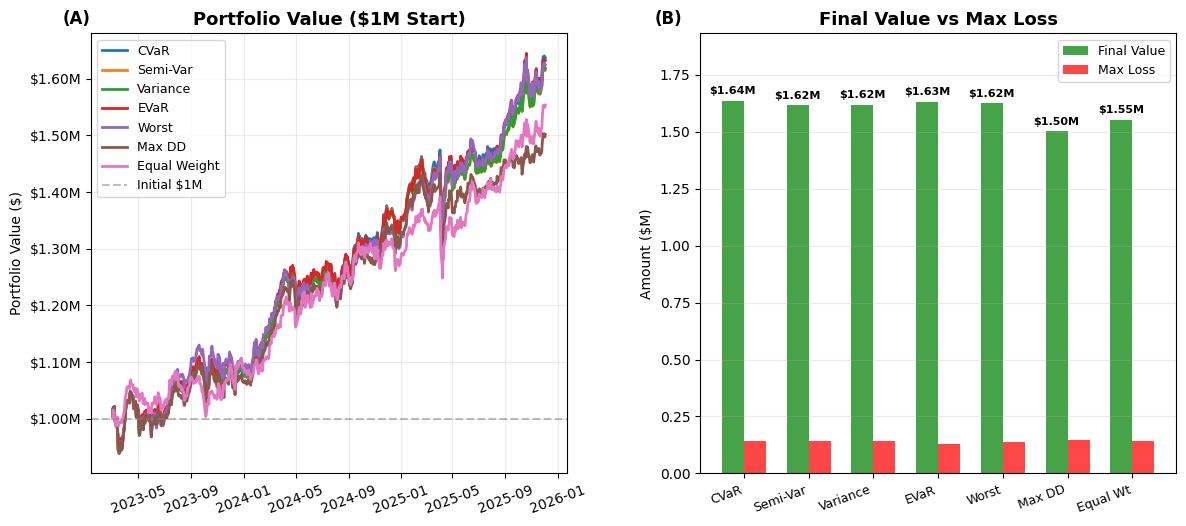

In [23]:
# Figure 2 — Portfolio value (A) and final value vs max loss (B)
import matplotlib.pyplot as plt
import numpy as np

names = list(portfolio_stats.keys())
short_names = ["CVaR", "Semi-Var", "Variance", "EVaR", "Worst", "Max DD", "Equal Wt"]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (A) Portfolio value over time
for name, stats in portfolio_stats.items():
    portfolio_value = INITIAL * (1 + stats["cumulative_returns"])
    ax1.plot(portfolio_value.index, portfolio_value.values, label=name, linewidth=2)
ax1.axhline(y=INITIAL, color="gray", linestyle="--", alpha=0.5, label="Initial $1M")
ax1.set_title("Portfolio Value ($1M Start)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Portfolio Value ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1e6:.2f}M"))
ax1.tick_params(axis="x", rotation=20)
ax1.legend(loc="upper left", fontsize=9, frameon=True)
ax1.grid(True, alpha=0.25)

# (B) Final value and max loss bar chart
final_values = [portfolio_stats[name]["final_value"] for name in names]
max_losses = [portfolio_stats[name]["max_loss"] for name in names]
x = np.arange(len(names))
width = 0.34
final_values_m = [v / 1e6 for v in final_values]
max_losses_m = [l / 1e6 for l in max_losses]
bars1 = ax2.bar(x - width / 2, final_values_m, width, label="Final Value", color="green", alpha=0.72)
ax2.bar(x + width / 2, max_losses_m, width, label="Max Loss", color="red", alpha=0.72)
ax2.set_ylabel("Amount ($M)")
ax2.set_title("Final Value vs Max Loss", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=20, ha="right", fontsize=9)
ax2.set_ylim(0, max(final_values_m) * 1.18)
ax2.legend(loc="upper right", fontsize=9, frameon=True)
for bar, value in zip(bars1, final_values_m):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(final_values_m) * 0.012,
        f"${value:.2f}M",
        ha="center", va="bottom", fontsize=8, fontweight="bold",
    )
ax2.grid(True, alpha=0.25, axis="y")

for label, ax in [("(A)", ax1), ("(B)", ax2)]:
    bbox = ax.get_position()
    fig2.text(bbox.x0 - 0.02, bbox.y1 + 0.04, label, fontsize=12, fontweight="bold", ha="left", va="bottom")

fig2.subplots_adjust(top=0.91, wspace=0.28)
fig2.canvas.draw()
fig2.savefig("../../Paper/Figures/Figure2.tif", dpi=300, bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

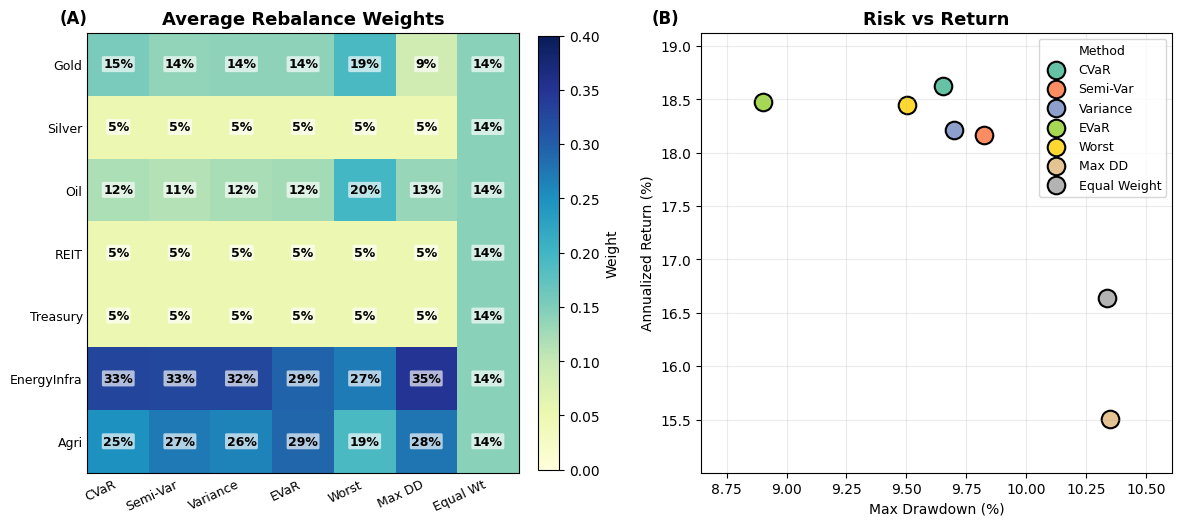

In [22]:
# Figure 3 — Average rebalance weights (A) and risk vs return (B)
import matplotlib.pyplot as plt
import numpy as np

names = list(portfolio_stats.keys())
short_names = ["CVaR", "Semi-Var", "Variance", "EVaR", "Worst", "Max DD", "Equal Wt"]

fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5.5))

# (A) Average rebalance weights heatmap
im = ax3.imshow(weights_df.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=0.4)
ax3.set_xticks(np.arange(len(weights_df.columns)))
ax3.set_yticks(np.arange(len(weights_df.index)))
ax3.set_xticklabels(short_names, rotation=25, ha="right", fontsize=9)
ax3.set_yticklabels(weights_df.index, fontsize=9)
ax3.tick_params(length=0)
for i in range(len(weights_df.index)):
    for j in range(len(weights_df.columns)):
        val = weights_df.iloc[i, j]
        ax3.text(
            j, i, f"{val:.0%}",
            ha="center", va="center", color="black",
            fontweight="bold", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.12", facecolor=(1, 1, 1, 0.65), edgecolor="none"),
        )
ax3.set_title("Average Rebalance Weights", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax3, label="Weight", fraction=0.046, pad=0.04)

# (B) Risk-return scatter
returns = [portfolio_stats[name]["annualized_mean"] * 100 for name in names]
risks = [portfolio_stats[name]["max_drawdown"] * 100 for name in names]
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
for i, name in enumerate(names):
    ax4.scatter(risks[i], returns[i], s=160, c=[colors[i]], edgecolors="black", linewidth=1.5, label=name)
ax4.set_xlabel("Max Drawdown (%)")
ax4.set_ylabel("Annualized Return (%)")
ax4.set_title("Risk vs Return", fontsize=13, fontweight="bold")
ax4.margins(x=0.18, y=0.16)
ax4.grid(True, alpha=0.25)
ax4.legend(loc="upper right", fontsize=9, frameon=True, title="Method", title_fontsize=9)

for label, ax in [("(A)", ax3), ("(B)", ax4)]:
    bbox = ax.get_position()
    fig3.text(bbox.x0 - 0.02, bbox.y1 + 0.04, label, fontsize=12, fontweight="bold", ha="left", va="bottom")

fig3.subplots_adjust(top=0.91, wspace=0.30)
fig3.canvas.draw()
fig3.savefig("../../Paper/Figures/Figure3.tif", dpi=300, bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()